# Ornstein-Ulenbeck, Black-Scholes, initiation `pytorch`

In [1]:
import numpy as np
import scipy.stats as sps
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
from numpy.random import default_rng, SeedSequence

sq = SeedSequence()
rng = default_rng(sq);

## Ornstein-Uhlenbeck

On considère $(X_t)_{t \in [0,T]}$ processus à valeurs dans $\mathbf{R}$ solution de l'EDS 
\begin{equation*}
    \operatorname{d}\! X_t = \lambda (\mu - X_t) \operatorname{d}\! t + \sigma \operatorname{d}\! W_t, \quad X_0 = x \in \mathbf{R},
\end{equation*}
où $\lambda > 0$, $\mu, \sigma \in \mathbf{R}$.

On pose $Y_t = e^{\lambda t} (X_t - \mu)$ qui vérifie 
\begin{equation*}
\begin{aligned}
    \operatorname{d}\! Y_t &= \lambda e^{\lambda t} (X_t - \mu) \operatorname{d}\! t + e^{\lambda t} \operatorname{d}\! X_t, \\
    &= \sigma e^{\lambda t} \operatorname{d}\! W_t,
\end{aligned}
\end{equation*}
et $Y_0 = x-\mu$. 

Le processus $(Y_t)_{t \in [0,T]}$ est une intégrale de Wiener, donc un processus de Markov et un processus Gaussien de fonction moyenne $m_Y(t) = x-\mu$ et de fonction de covariance 
\begin{equation*}
\begin{aligned}
    K_Y(s, t) &= \operatorname{cov}(Y_s, Y_t) = \sigma^2 \mathbf{E}\bigg[\int_0^s e^{\lambda u} \operatorname{d}\! W_u \int_0^t e^{\lambda u} \operatorname{d}\! W_u \bigg], \\
            &= \frac{\sigma^2}{2 \lambda} \big( e^{2 \lambda \min(s,t)} - 1 \big).
\end{aligned}
\end{equation*}
En particulier, 
\begin{equation*}
    \forall 0 \le s \le t, \quad \mathcal{L}\big(Y_t| \sigma(Y_u, u \le s)\big) 
    \sim \mathcal{N}\Bigl( Y_s ; \frac{\sigma^2}{2 \lambda} \bigl( e^{2 \lambda t} - e^{2 \lambda s}\bigr) \Bigr) 
\end{equation*}

On en déduit que $(X_t)_{t \in [0,T]}$ un aussi un processus Gaussien de fonction moyenne $m_X$ et de fonction de covariance $K_X$ définies par 
\begin{equation*}
    m_X(t) = \mu + (x-\mu) e^{-\lambda t} \quad \text{et} \quad 
    K_X(s, t) = \frac{\sigma^2}{2 \lambda} e^{-\lambda (s+t)} \big( e^{2 \lambda \min(s,t)} - 1 \big).
\end{equation*}
En particulier, 
\begin{equation*}
    \forall 0 \le s \le t, \quad \mathcal{L}\big(X_t| \sigma(X_u, u \le s)\big) 
    \simeq \mathcal{N}\Bigl( \mu + (X_s-\mu) e^{-\lambda(t-s)} ; \frac{\sigma^2}{2 \lambda} \bigl( 1 - e^{-2\lambda(t-s)} \bigr) \Bigr) 
\end{equation*}

In [2]:
lambd = 5
mu = 1.
sigma = 0.3
x0 = 3.0
T = 5

Au temps $T = 5$ on a $X_T$ qui suit une loi Normale de paramètres:

In [4]:
mean = mu + (x0-mu)*np.exp(-lambd*T)
var = sigma**2/(2*lambd)*(1-np.exp(-2*lambd*T))
print("mean:\t", mean)
print("var:\t", var)

mean:	 1.0000000000277758
var:	 0.009


### Question: Simulation via $Y$

Ecrire une fonction 
```
    ou_direct_np(noise, delta, x0, lambd, mu, sigma)
```
qui prend en argument `noise` un `np.array` de shape `(n, M)` où `n` est le nombre de pas de temps et `M` le nombre de trajectoires à simuler, `delta` est $\delta = T/n$ et `x0`, `lambd`, `mu` et `sigma` sont les paramètres du processus d'Ornstein-Uhlenbeck.

L'implémentation doit être la suivante: on simule les accroissements de $(Y_t)_{t \in [0,T]}$ aux instants $t_k = k \delta$, puis on reconstruit les $Y_{t_k}$ (via `np.cumsum`) et on obtient $X_{t_k}$ à partir de $Y_{t_k}$.

In [5]:
def ou_direct_np(noise, delta, x0, lambd, mu, sigma):
    n, M = noise.shape
    ts = (np.arange(n+1)*delta)[:,None]   # on ajoute un axe pour avoir un vecteur colonne 
    dY = np.empty((n+1, M))
    dY[0] = x0-mu
    dY[1:] = np.sqrt(sigma**2/(2*lambd)*(np.exp(2*lambd*ts[1:]) - np.exp(2*lambd*ts[:-1]))) * noise
    sample = mu + np.exp(-lambd*ts) * np.cumsum(dY, axis=0) #sample_Y
    return sample  # (n+1, M)

### Question: Simulation récursive

De façon similaire, écrire une fonction 
```
    ou_rec_np(noise, delta, x0, lambd, mu, sigma)
```
qui utilise une boucle `for` pour construire itérativement $X_{t_{k+1}}$ à partir de $X_{t_k}$ (les $M$ trajectoires en même temps).

In [6]:
def ou_rec_np(noise, delta, x0, lambd, mu, sigma):
    n, M = noise.shape
    kap_ = np.exp(-lambd*delta) 
    sig_ = np.sqrt(sigma**2/(2*lambd)*(1 - kap_**2))
    sample = np.empty((n+1, M))
    sample[0] = x0
    for k in range(1, n+1):
        sample[k] = mu + (sample[k-1] - mu) * kap_ + sig_ * noise[k-1]
    return sample

### Question: vérification code et visualisation

Vérifier en utilisant le même argument `noise` que les deux fonctions renvoient les mêmes trajectoires. Vérifier aussi la moyenne empirique et la variance empirique terminale.

Tracer 100 trajectoires.

In [7]:
# vérification des moments 
n, M = 100, 100000
delta = T/n
Gn = rng.standard_normal((n, M)) 

sample = ou_direct_np(Gn, delta, x0, lambd, mu, sigma)
print(sample[-1].mean(), sample[-1].var())

sample = ou_rec_np(Gn, delta, x0, lambd, mu, sigma)
print(sample[-1].mean(), sample[-1].var())

1.0001945106983618 0.009026750800928404
1.0001945106983618 0.009026750800928404


In [8]:
n, M = 100, 200
delta = T/n
Gn = rng.standard_normal((n, M)) 
sample = ou_direct_np(Gn, delta, x0, lambd, mu, sigma)
sample.shape

(101, 200)

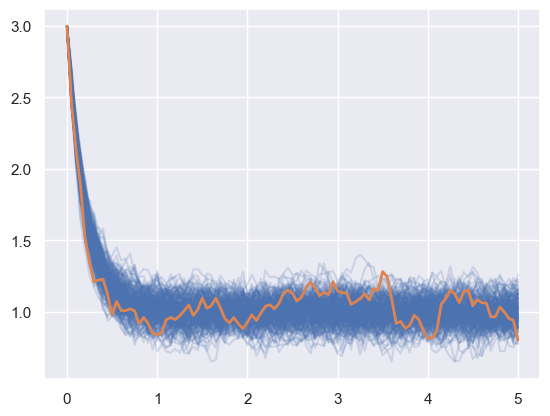

In [9]:
times = np.arange(n+1)*delta
for path in sample.T:
    sns.lineplot(x=times, y=path, color='C0', alpha=0.2)
sns.lineplot(x=times, y=sample[:,0], lw=2, color='C1');

### Question: comparaison des temps 

Comparer les temps de calcul pour différentes valeurs de `n` et `M`.

In [16]:
n, M = 100, 100000
delta = T/n   # T = 1
Gn = rng.standard_normal((n, M)) 

sample = ou_direct_np(Gn, delta, x0, lambd, mu, sigma)
print(sample[-1].mean(), sample[-1].var())

sample = ou_rec_np(Gn, delta, x0, lambd, mu, sigma)
print(sample[-1].mean(), sample[-1].var())

0.9999869983219588 0.00902395290731997
0.9999869983219588 0.00902395290731997


In [17]:
def simu_np(n, M, algo): 
    delta = T/n
    Gn = rng.standard_normal((n, M)) 
    if algo == 'direct':
        sample = ou_direct_np(Gn, delta, x0, lambd, mu, sigma)
    if algo == 'rec':
        sample = ou_rec_np(Gn, delta, x0, lambd, mu, sigma)
    return sample

In [20]:
n, M = 100, 100000
%timeit simu_np(n, M, "direct")
%timeit simu_np(n, M, "rec")

66.9 ms ± 314 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
40 ms ± 251 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


## Algorithmes en `pytorch`

Reprendre les deux fonctions précédentes pour adapter le code à `pytorch`: on remplace les `np.array` de `numpy` par des `torch.tensor` de `pytorch`.

[Documentation officielle à lire.](https://pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html)

### Question: Implémentation sur CPU

Ecrire des fonctions `ou_direct_torch` et `ou_rec_torch` pour utiliser `pytorch` à la place de `numpy`.

Il suffit d'importer le module `torch` et de remplacer les appels de `numpy` par les fonctions/objets équivalents en pytorch. 

In [27]:
import math 
import torch

def ou_direct_torch(noise, delta, x0, lambd, mu, sigma):
    n, M = noise.shape
    ts = (torch.arange(n+1)*delta)[:,None]
    dY = torch.empty((n+1, M))
    dY[0] = x0-mu
    dY[1:] = torch.sqrt(sigma**2/(2*lambd)*(torch.exp(2*lambd*ts[1:]) - torch.exp(2*lambd*ts[:-1]))) * noise
    sample = mu + torch.exp(-lambd*ts) * torch.cumsum(dY, axis=0) #sample_Y
    return sample

def ou_rec_torch(noise, delta, x0, lambd, mu, sigma):
    n, M = noise.shape
    kap_ = math.exp(-lambd*delta) # attention ce sont des réels 
    sig_ = math.sqrt(sigma**2/(2*lambd)*(1 - kap_**2)) # attention ce sont des réels 
    sample = torch.empty((n+1, M))
    sample[0] = x0
    for k in range(1, n+1):
        sample[k] = mu + (sample[k-1] - mu) * kap_ + sig_ * noise[k-1]
    return sample

In [30]:
print(torch.__version__)

2.9.1


### Question: Tester et comparer les temps 

Vérifier vos codes en calculant moyenne et variance sur l'échantillon au temps final. 

Mesurer les temps de calculs et les comparer avec `numpy`.

In [31]:
n, M = 100, 100000
delta = T/n
#Gn = rng.standard_normal((n, M)) 
Gn = torch.from_numpy(rng.standard_normal((n, M)))

sample = ou_direct_torch(Gn, delta, x0, lambd, mu, sigma)
print(sample[-1].mean(), sample[-1].var())

sample = ou_rec_torch(Gn, delta, x0, lambd, mu, sigma)
print(sample[-1].mean(), sample[-1].var())

tensor(0.9999) tensor(0.0090)
tensor(0.9999) tensor(0.0090)


In [32]:
def simu_cpu_torch(n, M, algo): 
    delta = T/n
    Gn = torch.from_numpy(rng.standard_normal((n, M)))
    if algo == 'direct':
        sample = ou_direct_torch(Gn, delta, x0, lambd, mu, sigma)
    if algo == 'rec':
        sample = ou_rec_torch(Gn, delta, x0, lambd, mu, sigma)
    return sample

In [33]:
n, M = 100, 100000
%timeit simu_cpu_torch(n, M, "direct")
%timeit simu_cpu_torch(n, M, "rec")

37.7 ms ± 229 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
43.5 ms ± 94 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


### Question: Implémentation sur un autre device

Pour utiliser un autre device, il faut modifier son code pour demander la création des tensors sur le device en question. 

Adapter le code précédent en ajoutant l'option `device` aux fonctions `ou_direct_torch` et `ou_rec_torch`.

In [34]:
if torch.cuda.is_available() and torch.backends.cuda.is_built():
    print("Utilisation du GPU")
    device = torch.device("cuda:0")
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    print("Utilisation du MPS")
    device = torch.device("mps")
else: 
    print("Utilisation du CPU")
    device = torch.device("cpu")

Utilisation du MPS


In [35]:
def ou_direct_torch(noise, delta, x0, lambd, mu, sigma, device):
    n, M = noise.shape
    ts = (torch.arange(n+1, device=device)*delta)[:,None]
    dY = torch.empty((n+1, M), device=device)
    dY[0] = x0-mu
    dY[1:] = torch.sqrt(sigma**2/(2*lambd)*(torch.exp(2*lambd*ts[1:]) - torch.exp(2*lambd*ts[:-1]))) * noise
    sample = mu + torch.exp(-lambd*ts) * torch.cumsum(dY, axis=0) #sample_Y
    return sample

def ou_rec_torch(noise, delta, x0, lambd, mu, sigma, device):
    n, M = noise.shape
    kap_ = math.exp(-lambd*delta) 
    sig_ = math.sqrt(sigma**2/(2*lambd)*(1 - kap_**2))
    sample = torch.empty((n+1, M), device=device)
    sample[0] = x0
    for k in range(1, n+1):
        sample[k] = mu + (sample[k-1] - mu) * kap_ + sig_ * noise[k-1]
    return sample

In [37]:
n, M = 100, 100000
delta = T/n
#Gn = torch.randn((n, M), device=device)
Gn = torch.from_numpy(rng.standard_normal((n, M))).float().to(device)

sample = ou_direct_torch(Gn, delta, x0, lambd, mu, sigma, device=device)
print(sample[-1].mean(), sample[-1].var())

sample = ou_rec_torch(Gn, delta, x0, lambd, mu, sigma, device=device)
print(sample[-1].mean(), sample[-1].var())

tensor(1.0000, device='mps:0') tensor(0.0090, device='mps:0')
tensor(1.0000, device='mps:0') tensor(0.0090, device='mps:0')


In [42]:
def simu_torch(n, M, algo, device): 
    delta = T/n
    #Gn = torch.from_numpy(rng.standard_normal((n, M))).float().to(device)
    Gn = torch.randn((n, M), device=device)
    if algo == 'direct':
        sample = ou_direct_torch(Gn, delta, x0, lambd, mu, sigma, device=device)
    if algo == 'rec':
        sample = ou_rec_torch(Gn, delta, x0, lambd, mu, sigma, device=device)
    return sample

In [43]:
%timeit simu_torch(n, M, "direct", device="cpu")
%timeit simu_torch(n, M, "rec", device="cpu")

60 ms ± 311 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
64.7 ms ± 164 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [44]:
%timeit simu_torch(n, M, "direct", device="mps")
%timeit simu_torch(n, M, "rec", device="mps")

4.56 ms ± 3.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
4.89 ms ± 459 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## Brownien géométrique, modèle de Black-Scholes

On considère $(S_t)_{t \in [0,T]}$ solution de l'EDS sur $[0,T]$
\begin{equation*}
    \operatorname{d}\!S_t = r S_t \operatorname{d}\!t + \sigma S_t \operatorname{d}\!B_t, \quad S_0 = x
\end{equation*}
c'est à dire 
\begin{equation*}
    S_t = x \exp \bigl((r- \sigma^2/2) t + \sigma B_t \bigr).
\end{equation*}

### Question: Simulation directe

Réfléchir à deux algorithmes différents: l'un en utilisant la transformation exponentielle appliquée à un Brownien (dilaté et translaté), l'autre en utilisant un produit cumulé `cumprod`.

Ecrire un code de simulation `numpy` puis `pytorch` pour simuler `M` trajectoires aux instants $t_k = k T/n$, $n \ge 1$.